In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from scipy.integrate import solve_ivp
from scipy.special import kn
from scipy.integrate import cumulative_trapezoid
import pandas as pd

In [3]:
def Y_eq(x):
  return 0.05 * x**2 * kn(2, x)


def boltzmann_riccati(x, y, lambda_val):
  Y = y[0]
  Yeq = Y_eq(x)

  if Y < Yeq:
    Y = Yeq

  dY_dx = -(lambda_val / x**2) * (Y**2 - Yeq**2)
  return [dY_dx]


x_start, x_end = 0.1, 1000
x_eval = np.logspace(np.log10(x_start), np.log10(x_end), 1000)

<>:21: SyntaxWarning: invalid escape sequence '\l'
<>:21: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_3397550/540850589.py:21: SyntaxWarning: invalid escape sequence '\l'
  plt.text(x_end * 1.15, Y_sol[-1], f'$\lambda = 10^{int(np.log10(lam))}$',


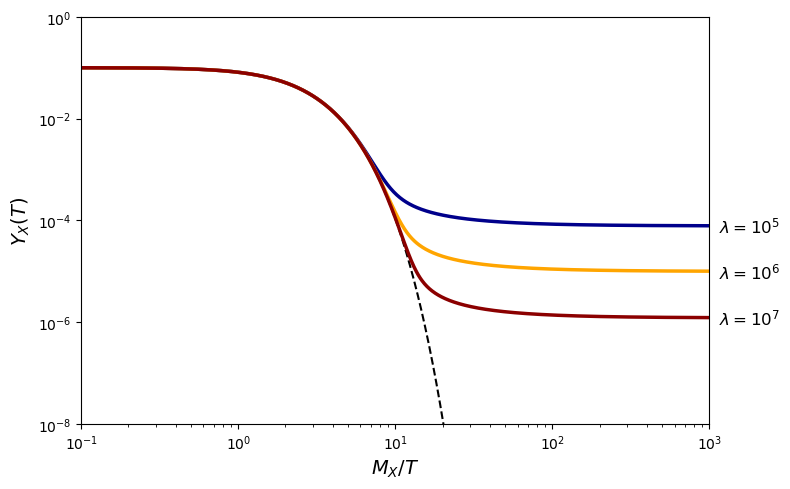

In [4]:
y0 = [Y_eq(x_start)]

lambdas = [1e5, 1e6, 1e7]
colores = ['darkblue', 'orange', 'darkred']


plt.figure(figsize=(8, 5))

plt.plot(x_eval, Y_eq(x_eval), 'k--', lw=1.5)


for lam, color in zip(lambdas, colores):

    sol = solve_ivp(boltzmann_riccati, [x_start, x_end], y0,
                    method='Radau', t_eval=x_eval, args=(lam,),
                    rtol=1e-9, atol=1e-13)

    Y_sol = sol.y[0]
    plt.plot(sol.t, Y_sol, color=color, lw=2.5)

    plt.text(x_end * 1.15, Y_sol[-1], f'$\lambda = 10^{int(np.log10(lam))}$',
             verticalalignment='center', fontsize=12)


plt.xscale('log')
plt.yscale('log')

plt.xlim(0.1, 1000)
plt.ylim(1e-8, 1e-0)

plt.xlabel(r'$M_X / T$', fontsize=14)
plt.ylabel(r'$Y_X(T)$', fontsize=14)

plt.tight_layout()
plt.show()